This analysis explores Walmart’s historical retail sales data to identify key trends, seasonal patterns, and variations in sales across departments and stores over time. Monthly sales were analyzed using time-series techniques such as moving averages and seasonal analysis to better understand underlying patterns and fluctuations. In addition, simple forecasting methods, including rolling mean and exponential smoothing, were applied to estimate future sales and evaluate their predictive performance. The analysis provides useful insights into sales behavior and can support better inventory planning, demand forecasting, and business decision-making.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [6]:
df = pd.read_csv("train - Walmart Sales Forecast.csv")

In [7]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [9]:
df.shape

(421570, 5)

In [10]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

In [11]:
df.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [12]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [13]:
df.duplicated().sum()

0

In [14]:
df["Store"].nunique()

45

In [15]:
df["Dept"].nunique()

81

In [16]:
df["Date"].min(), df["Date"].max()

('2010-02-05', '2012-10-26')

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df["Date"].dtype

dtype('<M8[ns]')

In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

In [20]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name,Quarter
0,1,1,2010-02-05,24924.50,False,2010,2,February,1
1,1,1,2010-02-12,46039.49,True,2010,2,February,1
2,1,1,2010-02-19,41595.55,False,2010,2,February,1
3,1,1,2010-02-26,19403.54,False,2010,2,February,1
4,1,1,2010-03-05,21827.90,False,2010,3,March,1


In [21]:
monthly_sales = (
    df.set_index("Date")
      .resample("ME")["Weekly_Sales"]
      .sum()
      .reset_index()
)

In [22]:
monthly_sales.rename(
    columns={"Weekly_Sales": "Monthly_Sales"},
    inplace=True
)

In [23]:
monthly_sales.head()

,Date,Monthly_Sales
0,2010-02-28,1.903330e+08
1,2010-03-31,1.819198e+08
2,2010-04-30,2.314124e+08
3,2010-05-31,1.867109e+08
4,2010-06-30,1.922462e+08


In [24]:
pd.set_option("display.float_format", "{:,.2f}".format)

monthly_sales.head()

,Date,Monthly_Sales
0,2010-02-28,"190,332,983.04"
1,2010-03-31,"181,919,802.50"
2,2010-04-30,"231,412,368.05"
3,2010-05-31,"186,710,934.34"
4,2010-06-30,"192,246,172.36"


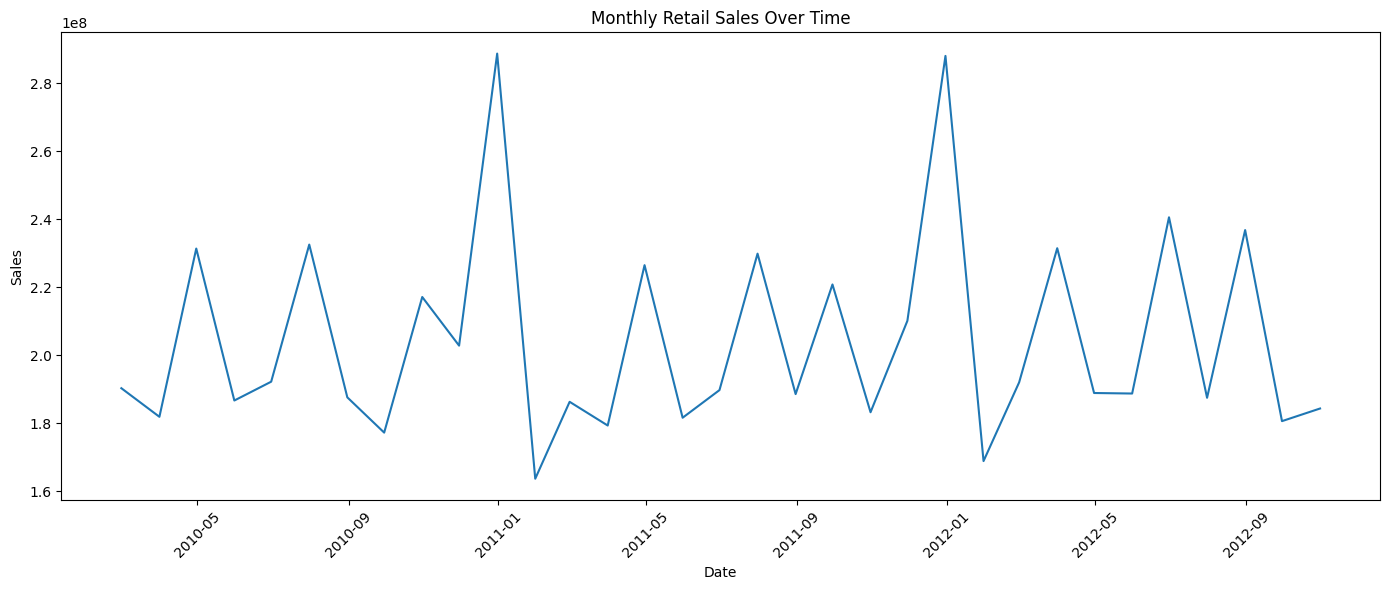

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Monthly_Sales"]
)

plt.title("Monthly Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
monthly_sales["MA_3"] = (
    monthly_sales["Monthly_Sales"]
    .rolling(window=3)
    .mean()
)

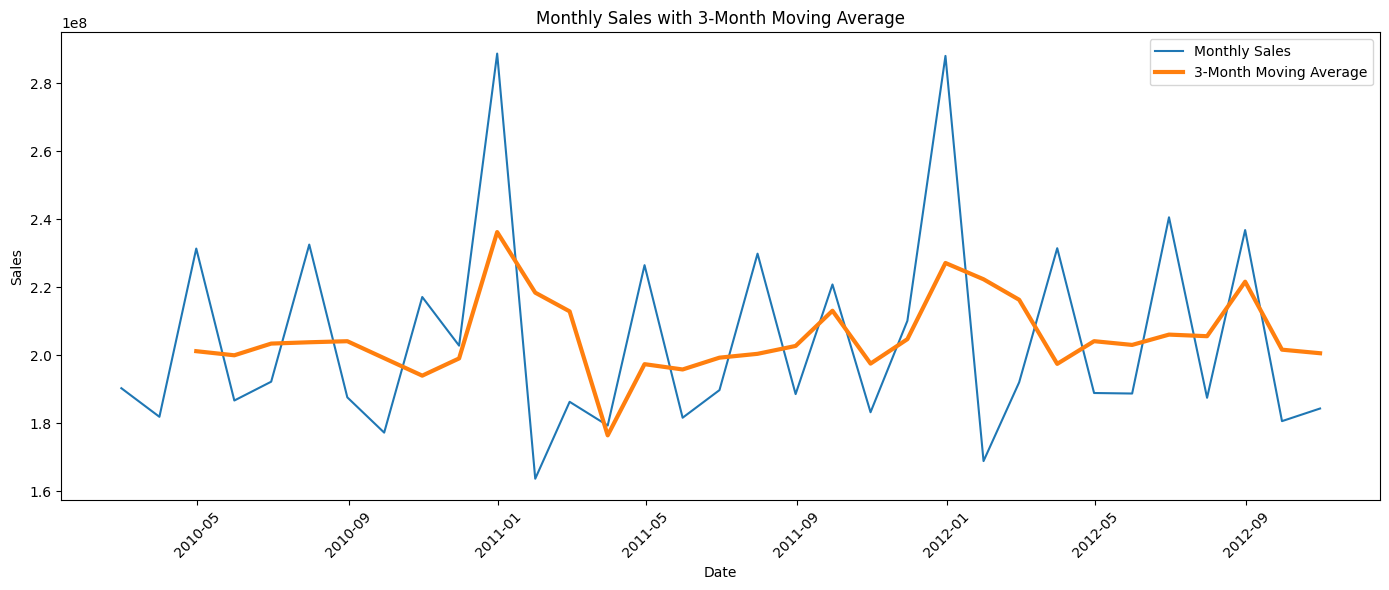

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Monthly_Sales"],
    label="Monthly Sales"
)

plt.plot(
    monthly_sales["Date"],
    monthly_sales["MA_3"],
    label="3-Month Moving Average",
    linewidth=3
)

plt.title("Monthly Sales with 3-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
monthly_sales["MA_6"] = (
    monthly_sales["Monthly_Sales"]
    .rolling(window=6)
    .mean()
)

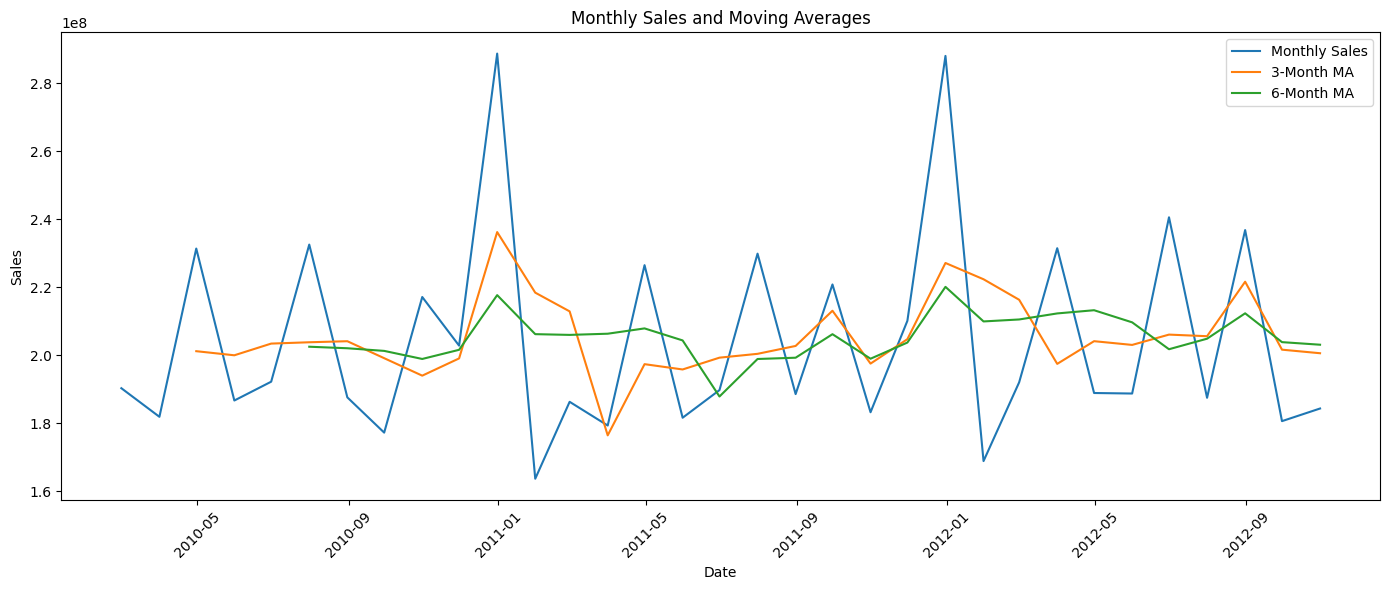

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Monthly_Sales"],
    label="Monthly Sales"
)

plt.plot(
    monthly_sales["Date"],
    monthly_sales["MA_3"],
    label="3-Month MA"
)

plt.plot(
    monthly_sales["Date"],
    monthly_sales["MA_6"],
    label="6-Month MA"
)

plt.title("Monthly Sales and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
seasonality = (
    df.groupby("Month")["Weekly_Sales"]
      .sum()
      .reset_index()
)

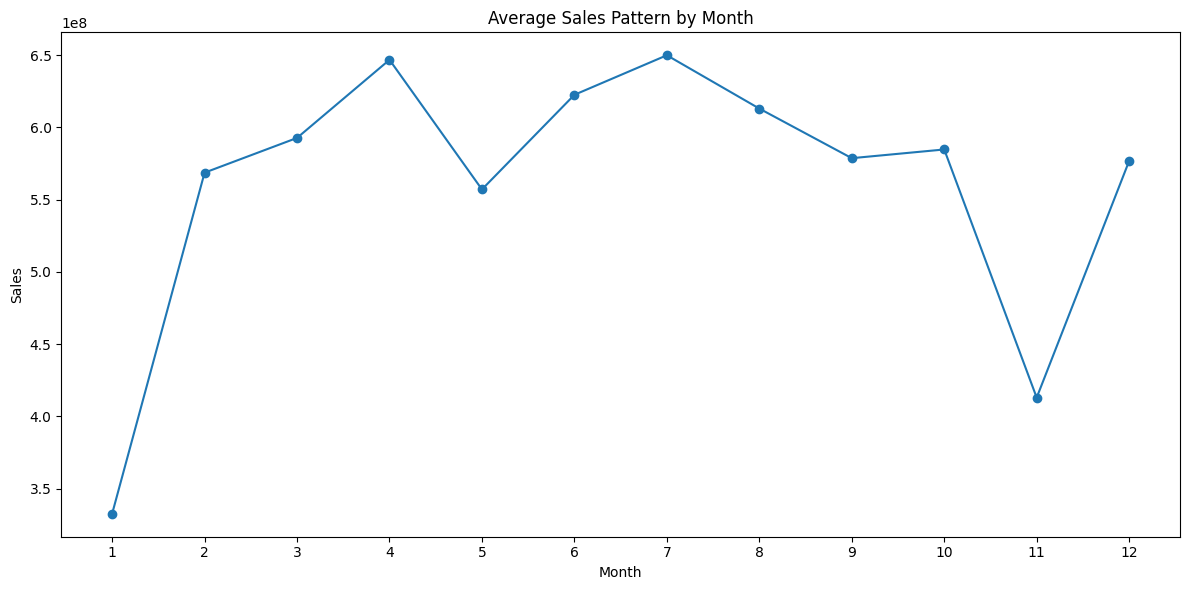

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    seasonality["Month"],
    seasonality["Weekly_Sales"],
    marker="o"
)

plt.title("Average Sales Pattern by Month")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [32]:
monthly_by_period = (
    df.groupby(["Year", "Month"])["Weekly_Sales"]
      .sum()
      .reset_index()
)

In [33]:
seasonality = (
    monthly_by_period.groupby("Month")["Weekly_Sales"]
    .mean()
    .reset_index()
)

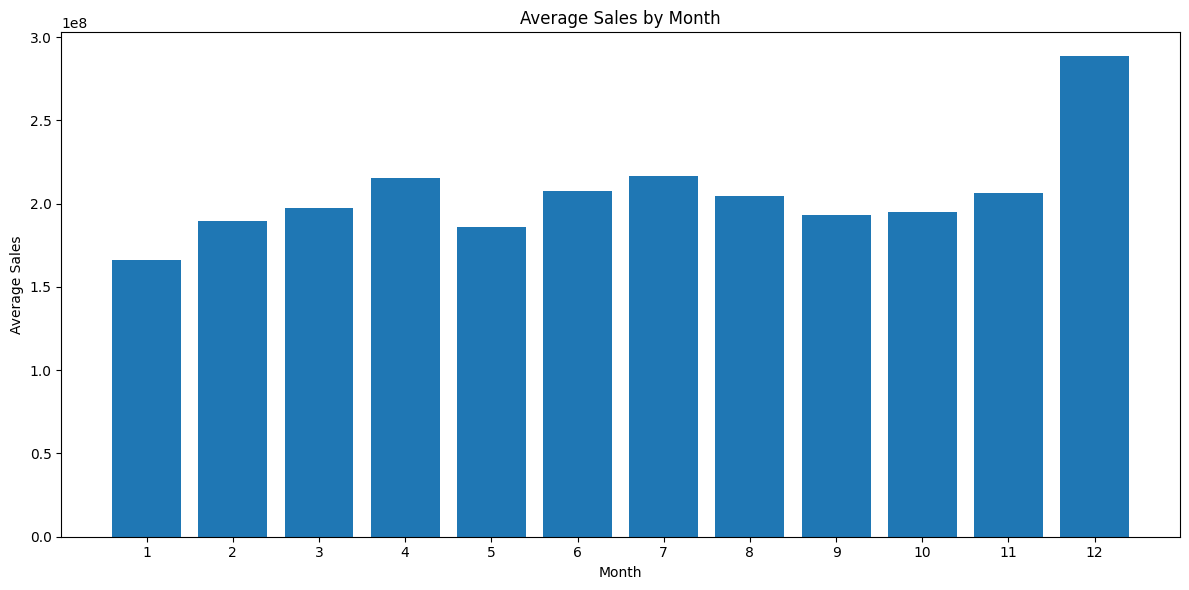

In [34]:
plt.figure(figsize=(12, 6))

plt.bar(
    seasonality["Month"],
    seasonality["Weekly_Sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [35]:
year_month_sales = (
    df.groupby(["Year", "Month"])["Weekly_Sales"]
      .sum()
      .reset_index()
)

In [36]:
sales_pivot = year_month_sales.pivot(
    index="Year",
    columns="Month",
    values="Weekly_Sales"
)

In [37]:
sales_pivot

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2010,NaN,"190,332,983.04","181,919,802.50","231,412,368.05","186,710,934.34","192,246,172.36","232,580,125.98","187,640,110.89","177,267,896.37","217,161,824.02","202,853,370.14","288,760,532.72"
2011,"163,703,966.83","186,331,327.87","179,356,448.29","226,526,510.97","181,648,158.16","189,773,385.19","229,911,398.87","188,599,332.25","220,847,738.42","183,261,283.15","210,162,354.87","288,078,102.48"
2012,"168,894,471.66","192,063,579.54","231,509,650.49","188,920,905.95","188,766,479.45","240,610,329.29","187,509,452.40","236,850,765.68","180,645,544.47","184,361,680.42",NaN,NaN


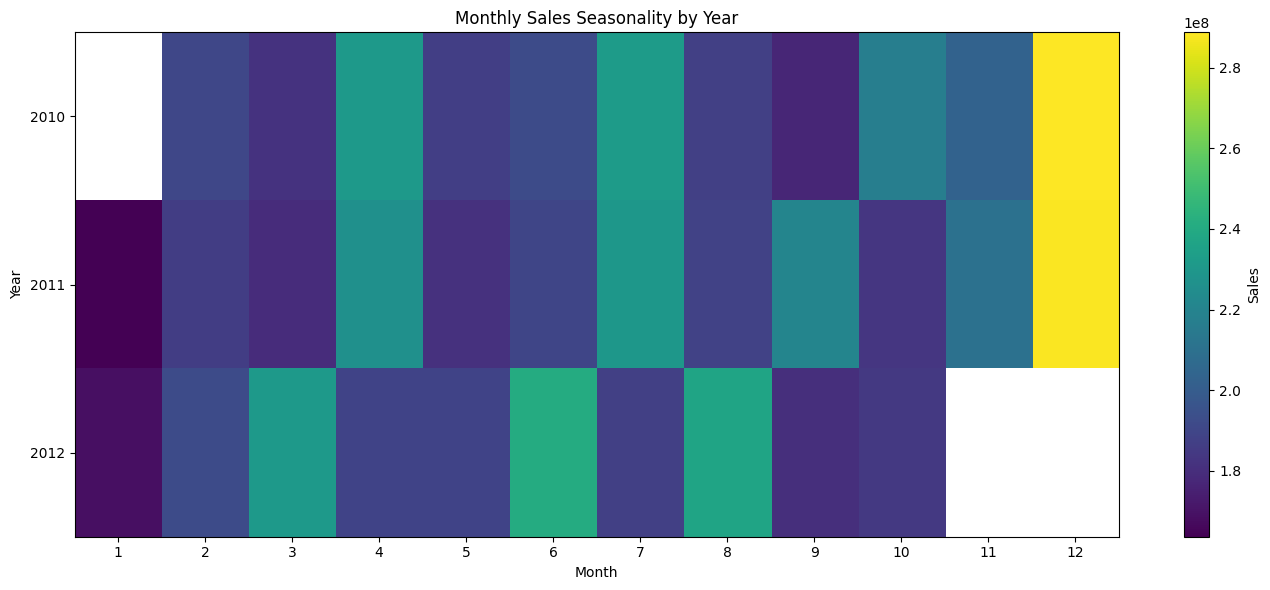

In [38]:
plt.figure(figsize=(14, 6))

plt.imshow(
    sales_pivot,
    aspect="auto"
)

plt.colorbar(label="Sales")

plt.title("Monthly Sales Seasonality by Year")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    range(len(sales_pivot.columns)),
    sales_pivot.columns
)

plt.yticks(
    range(len(sales_pivot.index)),
    sales_pivot.index
)

plt.tight_layout()
plt.show()

In [39]:
dept_sales = (
    df.groupby("Dept")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

In [40]:
dept_sales.head(10)

Dept
92   483,943,341.87
95   449,320,162.52
38   393,118,136.92
72   305,725,152.21
90   291,068,463.68
40   288,936,022.05
2    280,611,174.43
91   216,781,705.73
13   197,321,569.95
8    194,280,780.73
Name: Weekly_Sales, dtype: float64

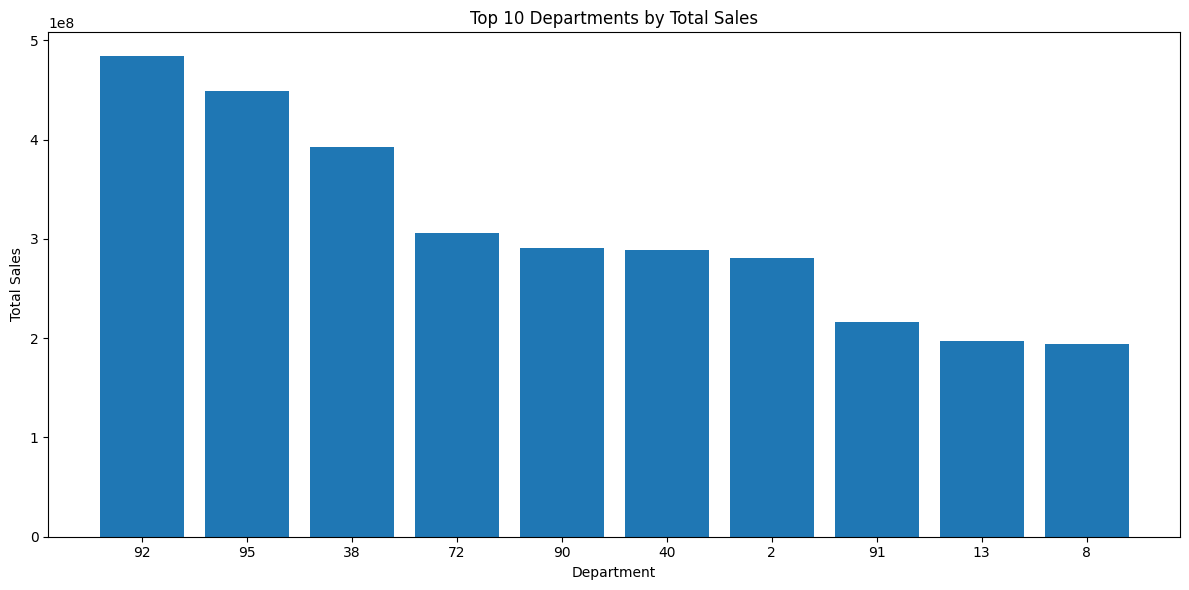

In [41]:
top_depts = dept_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_depts.index.astype(str),
    top_depts.values
)

plt.title("Top 10 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [42]:
top_5_depts = dept_sales.head(5).index

In [43]:
dept_monthly = (
    df[df["Dept"].isin(top_5_depts)]
    .groupby([
        pd.Grouper(key="Date", freq="ME"),
        "Dept"
    ])["Weekly_Sales"]
    .sum()
    .reset_index()
)

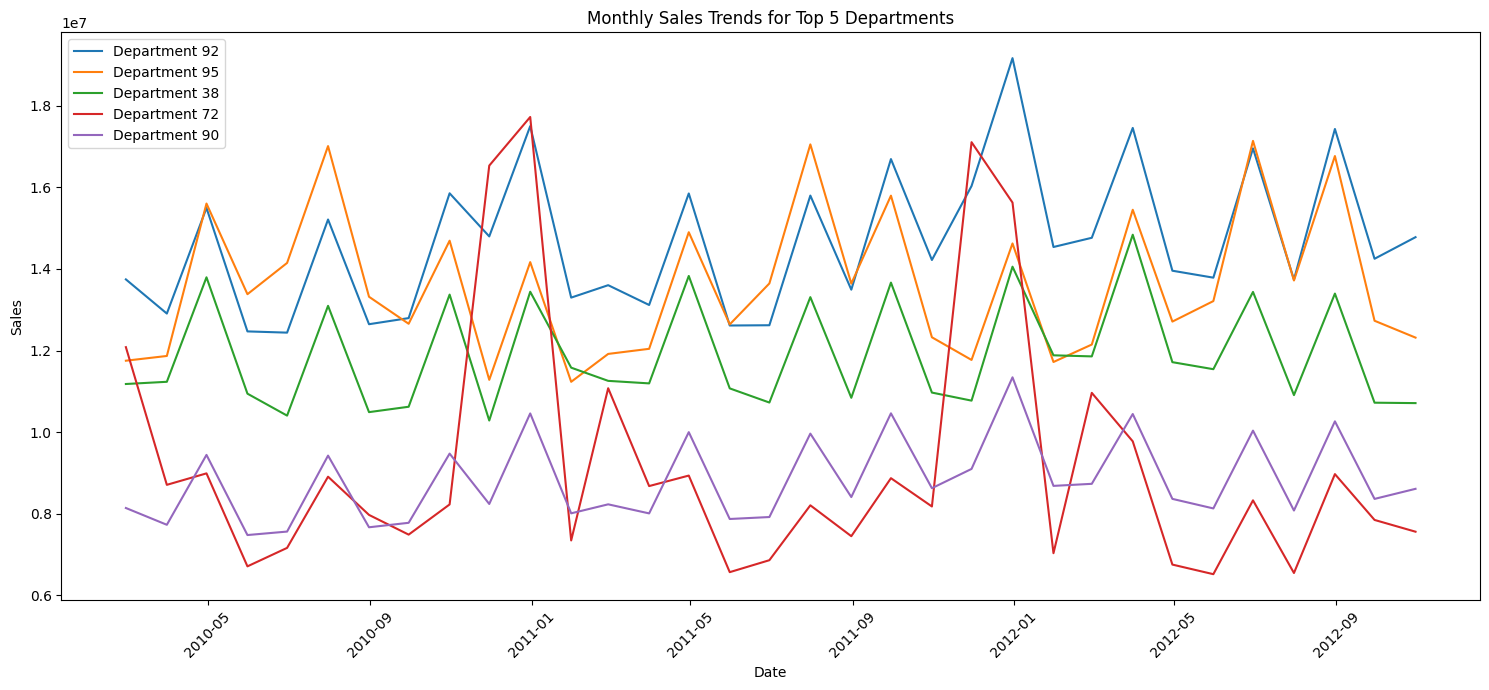

In [44]:
plt.figure(figsize=(15, 7))

for dept in top_5_depts:
    dept_data = dept_monthly[
        dept_monthly["Dept"] == dept
    ]

    plt.plot(
        dept_data["Date"],
        dept_data["Weekly_Sales"],
        label=f"Department {dept}"
    )

plt.title("Monthly Sales Trends for Top 5 Departments")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [45]:
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

In [46]:
store_sales.head(10)

Store
20   301,397,792.46
4    299,543,953.38
14   288,999,911.34
13   286,517,703.80
2    275,382,440.98
10   271,617,713.89
27   253,855,916.88
6    223,756,130.64
1    222,402,808.85
39   207,445,542.47
Name: Weekly_Sales, dtype: float64

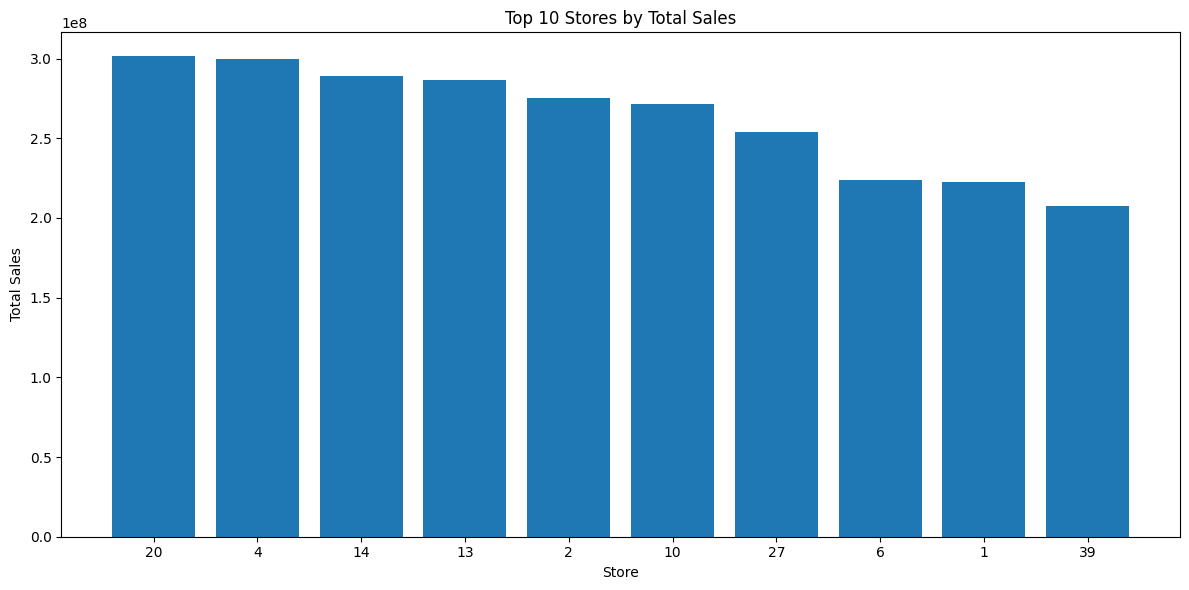

In [47]:
top_stores = store_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_stores.index.astype(str),
    top_stores.values
)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [48]:
top_5_stores = store_sales.head(5).index

In [49]:
store_monthly = (
    df[df["Store"].isin(top_5_stores)]
    .groupby([
        pd.Grouper(key="Date", freq="ME"),
        "Store"
    ])["Weekly_Sales"]
    .sum()
    .reset_index()
)

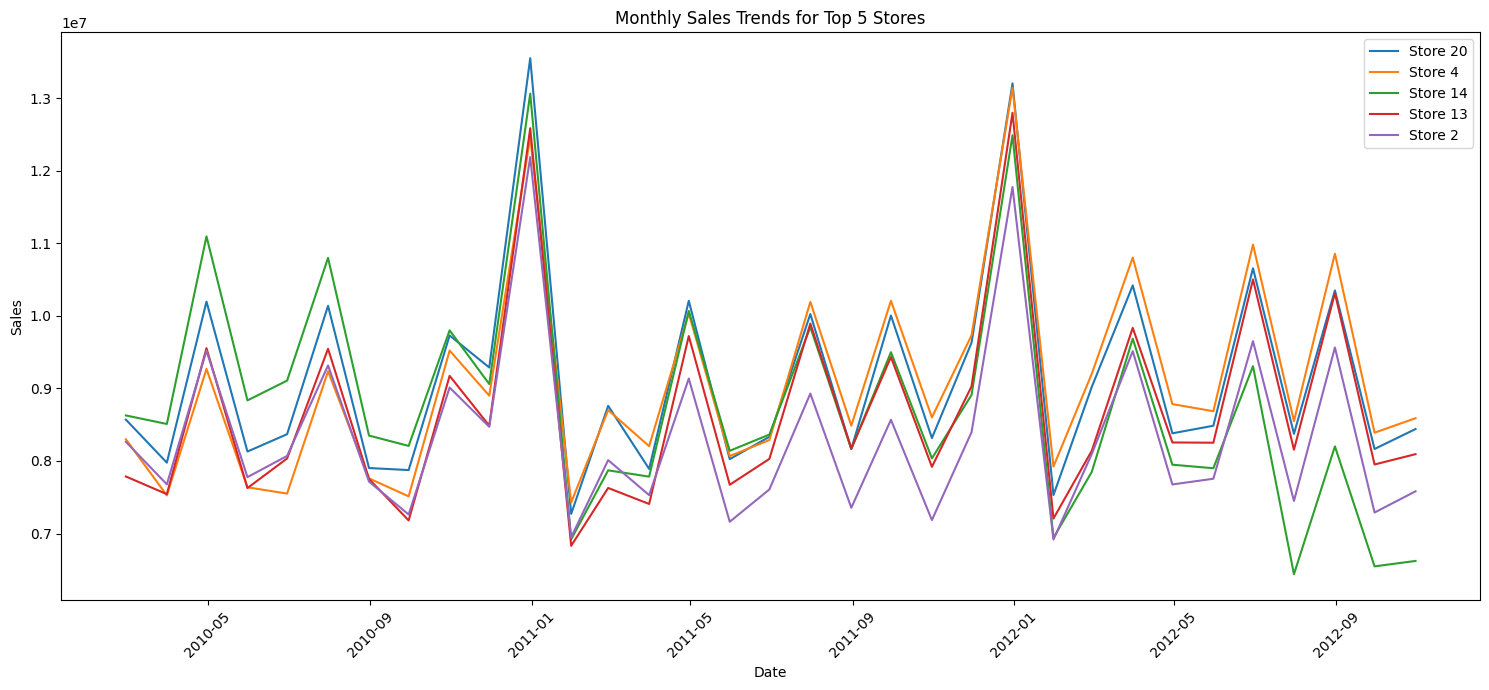

In [50]:
plt.figure(figsize=(15, 7))

for store in top_5_stores:

    store_data = store_monthly[
        store_monthly["Store"] == store
    ]

    plt.plot(
        store_data["Date"],
        store_data["Weekly_Sales"],
        label=f"Store {store}"
    )

plt.title("Monthly Sales Trends for Top 5 Stores")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
annual_sales = (
    df.groupby("Year")["Weekly_Sales"]
      .sum()
      .reset_index()
)

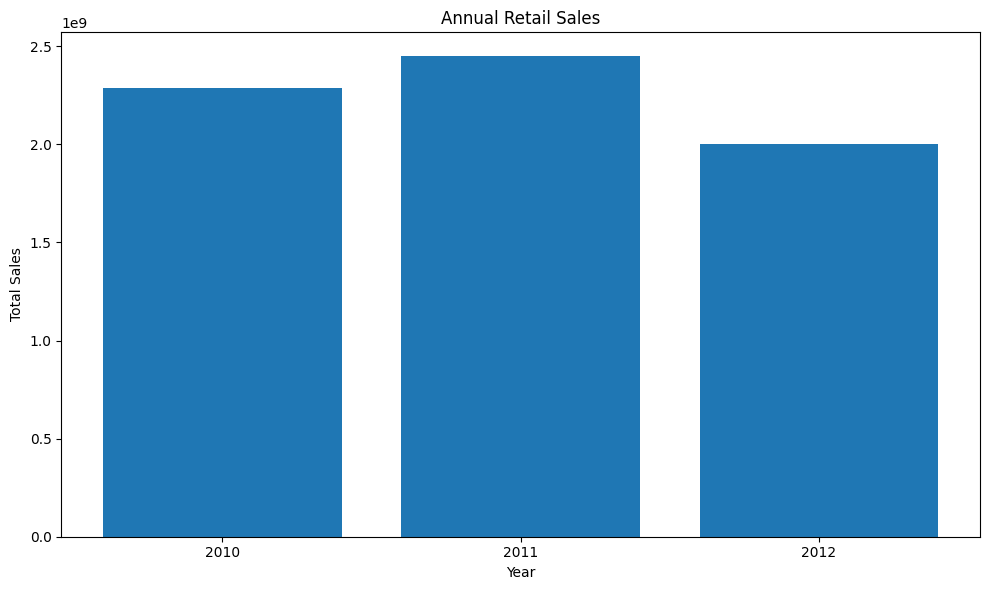

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    annual_sales["Year"].astype(str),
    annual_sales["Weekly_Sales"]
)

plt.title("Annual Retail Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [53]:
annual_sales["YoY_Growth"] = (
    annual_sales["Weekly_Sales"]
    .pct_change() * 100
)

In [54]:
annual_sales

,Year,Weekly_Sales,YoY_Growth
0,2010,"2,288,886,120.41",NaN
1,2011,"2,448,200,007.35",6.96
2,2012,"2,000,132,859.35",-18.30


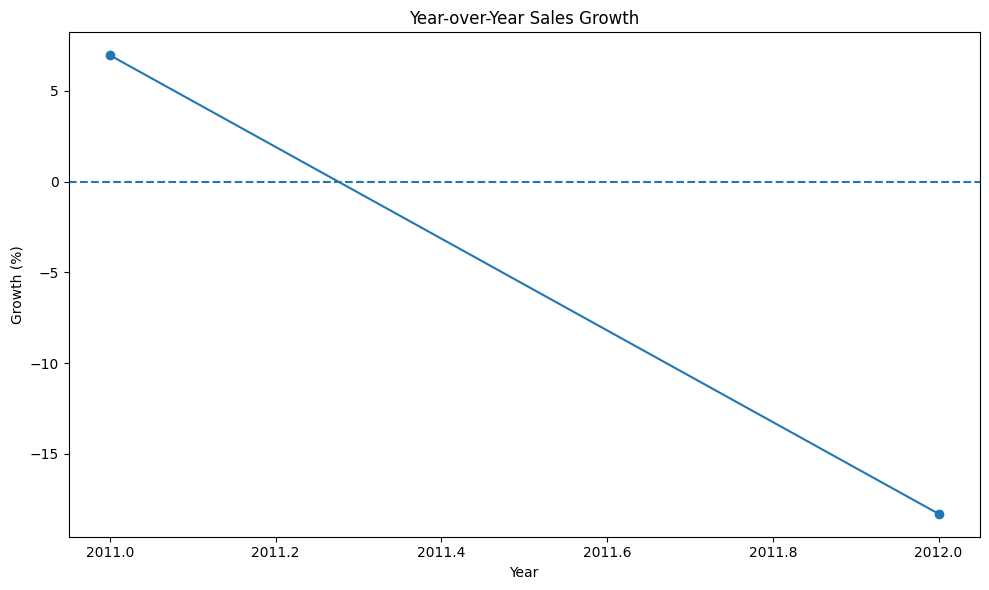

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    annual_sales["Year"],
    annual_sales["YoY_Growth"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Year-over-Year Sales Growth")
plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

In [56]:
holiday_sales = (
    df.groupby("IsHoliday")["Weekly_Sales"]
      .mean()
      .reset_index()
)

In [57]:
holiday_sales

,IsHoliday,Weekly_Sales
0,False,"15,901.45"
1,True,"17,035.82"


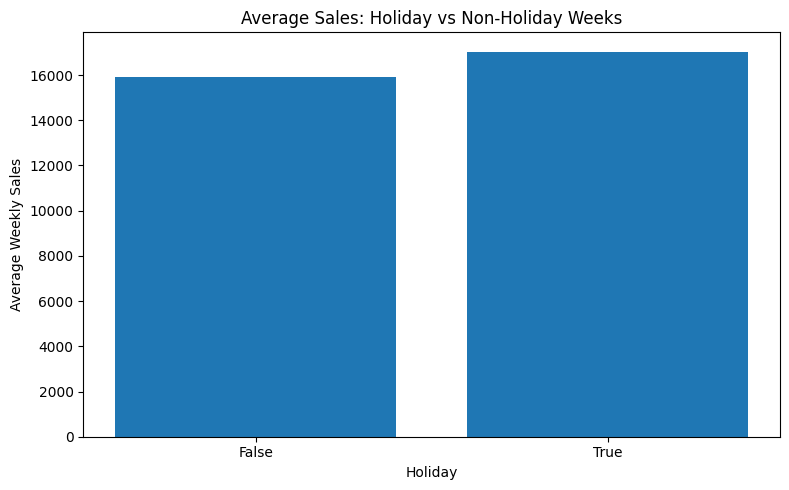

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    holiday_sales["IsHoliday"].astype(str),
    holiday_sales["Weekly_Sales"]
)

plt.title("Average Sales: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")

plt.tight_layout()
plt.show()

In [59]:
ts = monthly_sales.set_index("Date")["Monthly_Sales"]

In [60]:
ts.head()

Date
2010-02-28   190,332,983.04
2010-03-31   181,919,802.50
2010-04-30   231,412,368.05
2010-05-31   186,710,934.34
2010-06-30   192,246,172.36
Name: Monthly_Sales, dtype: float64

In [61]:
train = ts.iloc[:-6]
test = ts.iloc[-6:]

In [62]:
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 27
Testing observations: 6


In [63]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

c:\Users\basmala elhabshy\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [64]:
fit = model.fit()

In [65]:
forecast = fit.forecast(6)

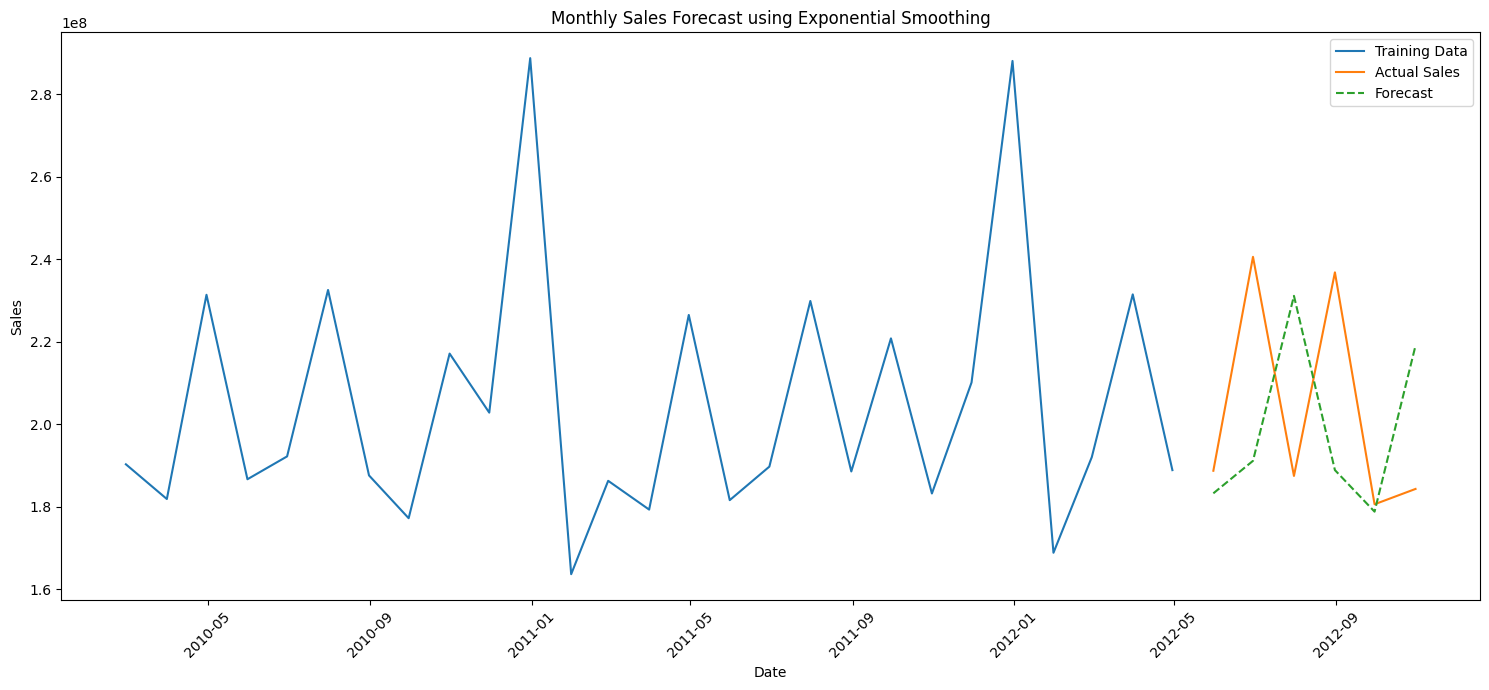

In [66]:
plt.figure(figsize=(15, 7))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales"
)

plt.plot(
    forecast.index,
    forecast,
    label="Forecast",
    linestyle="--"
)

plt.title("Monthly Sales Forecast using Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [68]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 30498311.407346193
RMSE: 36250356.98079927


In [69]:
rolling_forecast = (
    ts.rolling(window=3)
      .mean()
)

In [70]:
last_3_months_avg = train.iloc[-3:].mean()

rolling_predictions = pd.Series(
    last_3_months_avg,
    index=test.index
)

In [71]:
rolling_mae = mean_absolute_error(
    test,
    rolling_predictions
)

rolling_rmse = np.sqrt(
    mean_squared_error(
        test,
        rolling_predictions
    )
)

print("Rolling Mean MAE:", rolling_mae)
print("Rolling Mean RMSE:", rolling_rmse)

Rolling Mean MAE: 24084560.36944445
Rolling Mean RMSE: 25352434.67535117


In [72]:
forecast_comparison = pd.DataFrame({
    "Actual": test,
    "Exponential_Smoothing": forecast,
    "Rolling_Mean": rolling_predictions
})

In [73]:
forecast_comparison

,Actual,Exponential_Smoothing,Rolling_Mean
2012-05-31,"188,766,479.45","183,296,414.26","204,164,711.99"
2012-06-30,"240,610,329.29","191,174,135.09","204,164,711.99"
2012-07-31,"187,509,452.40","231,152,912.73","204,164,711.99"
2012-08-31,"236,850,765.68","188,927,391.82","204,164,711.99"
2012-09-30,"180,645,544.47","178,857,320.40","204,164,711.99"
2012-10-31,"184,361,680.42","219,090,231.22","204,164,711.99"


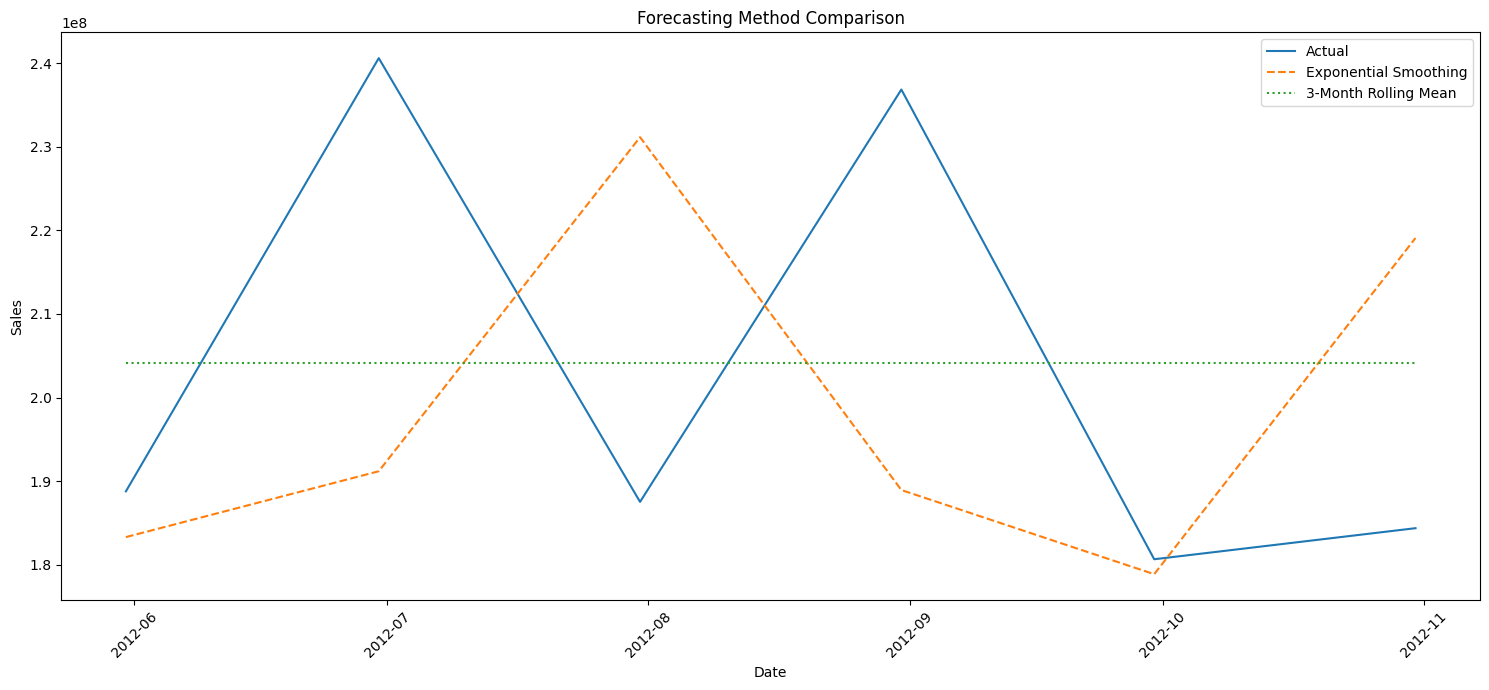

In [74]:
plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Exponential Smoothing",
    linestyle="--"
)

plt.plot(
    test.index,
    rolling_predictions,
    label="3-Month Rolling Mean",
    linestyle=":"
)

plt.title("Forecasting Method Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [75]:
comparison = pd.DataFrame({
    "Model": [
        "3-Month Rolling Mean",
        "Exponential Smoothing"
    ],
    "MAE": [
        rolling_mae,
        mae
    ],
    "RMSE": [
        rolling_rmse,
        rmse
    ]
})

comparison

,Model,MAE,RMSE
0,3-Month Rolling Mean,"24,084,560.37","25,352,434.68"
1,Exponential Smoothing,"30,498,311.41","36,250,356.98"


In [76]:
best_month = seasonality.loc[
    seasonality["Weekly_Sales"].idxmax()
]

worst_month = seasonality.loc[
    seasonality["Weekly_Sales"].idxmin()
]

print("Best month:", best_month["Month"])
print("Worst month:", worst_month["Month"])

Best month: 12.0
Worst month: 1.0


In [77]:
best_department = dept_sales.idxmax()
best_department_sales = dept_sales.max()

print("Best Department:", best_department)
print("Sales:", best_department_sales)

Best Department: 92
Sales: 483943341.87


In [78]:
best_store = store_sales.idxmax()
best_store_sales = store_sales.max()

print("Best Store:", best_store)
print("Sales:", best_store_sales)

Best Store: 20
Sales: 301397792.46


Task 7 - Time Series Breakdown of Retail Sales
│
├── 1. Project Overview
│
├── 2. Import Libraries
│
├── 3. Load Dataset
│
├── 4. Data Understanding
│   ├── Shape
│   ├── Columns
│   ├── Data Types
│   ├── Missing Values
│   └── Duplicates
│
├── 5. Data Cleaning
│   └── Date Conversion
│
├── 6. Feature Engineering
│   ├── Year
│   ├── Month
│   ├── Month Name
│   └── Quarter
│
├── 7. Monthly Sales Aggregation
│
├── 8. Overall Sales Trend
│
├── 9. Moving Averages
│   ├── 3-Month MA
│   └── 6-Month MA
│
├── 10. Seasonal Analysis
│   ├── Monthly Pattern
│   ├── Year × Month
│   └── Seasonal Heatmap
│
├── 11. Department Analysis
│   ├── Top Departments
│   └── Department Trends
│
├── 12. Store Analysis
│   ├── Top Stores
│   └── Store Trends
│
├── 13. Yearly Analysis
│   └── YoY Growth
│
├── 14. Holiday Analysis
│
├── 15. BONUS - Forecasting
│   ├── Train/Test Split
│   ├── Rolling Mean
│   ├── Exponential Smoothing
│   ├── MAE
│   └── RMSE
│
└── 16. Business Insights & Conclusion

Final Project Story
Raw Weekly Sales
       ↓
Data Cleaning
       ↓
Convert Dates
       ↓
Create Time Features
       ↓
Aggregate Weekly → Monthly
       ↓
       ├── Trend Analysis
       │
       ├── Moving Averages
       │
       ├── Seasonality
       │
       ├── Department Analysis
       │
       ├── Store Analysis
       │
       └── Holiday Analysis
              ↓
       Forecasting
       ├── Rolling Mean
       └── Exponential Smoothing
              ↓
       Model Evaluation
       ├── MAE
       └── RMSE
              ↓
       Business Insights